# Experiment 12: Hypothesis Testing — Independent Two-Sample T-Test

**AIM:**  
To conduct Independent Two-Sample T-Tests using `scipy.stats.ttest_ind` to compare clinical feature means (Glucose, BMI) between Diabetic (`Outcome = 1`) and Non-Diabetic (`Outcome = 0`) cohorts.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, SciPy, Matplotlib, Seaborn  

---
### THEORY:
- **Independent Two-Sample T-Test (Welch's T-Test)**: Compares the means of two independent groups without assuming equal population variances:
  $$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$
- **Hypotheses**:
  - **Null Hypothesis ($H_0$)**: $\mu_1 = \mu_2$ (Mean Glucose is identical between non-diabetic and diabetic groups).
  - **Alternative Hypothesis ($H_1$)**: $\mu_1 \neq \mu_2$ (Mean Glucose differs significantly between the two groups).

---
### PROCEDURE:
1. Load both UCI Diabetes and Pima Indians Diabetes datasets.
2. Partition samples by class label (`Outcome = 0` vs. `Outcome = 1`).
3. Compute group means and execute two-sample t-tests using `scipy.stats.ttest_ind(..., equal_var=False)`.
4. Analyze t-statistic, p-value, and clinical significance at $\alpha = 0.05$.
5. Visualize comparative distributions with boxplots.

## 1. Import Libraries & Load Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

uci_diabetes = pd.read_csv('uci_diabetes.csv')
pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)
print('Datasets loaded successfully!')

Datasets loaded successfully!


## 2. Perform Independent Two-Sample T-Tests

In [2]:
def perform_ttest(df, feature, group_col, dataset_name):
    group0 = df[df[group_col] == 0][feature].dropna()
    group1 = df[df[group_col] == 1][feature].dropna()
    t_stat, p_val = ttest_ind(group0, group1, equal_var=False)
    print(f'{dataset_name} - T-Test for {feature} (Outcome 0 vs 1):')
    print(f'Non-Diabetic Mean: {group0.mean():.2f}')
    print(f'Diabetic Mean: {group1.mean():.2f}')
    print(f'T-Statistic: {t_stat:.4f} | P-Value: {p_val:.6f}')
    if p_val < 0.05:
        print('Statistically Significant Difference (p < 0.05)')
    else:
        print('No Statistically Significant Difference (p >= 0.05)')
    return t_stat, p_val

perform_ttest(uci_diabetes, 'Glucose', 'Outcome', 'UCI Diabetes')
print()
perform_ttest(pima_diabetes, 'Glucose', 'Outcome', 'Pima Indians Diabetes')

UCI Diabetes - T-Test for Glucose (Outcome 0 vs 1):
Non-Diabetic Mean: 107.89
Diabetic Mean: 143.35
T-Statistic: -6.0024 | P-Value: 0.000000
Statistically Significant Difference (p < 0.05)

Pima Indians - T-Test for Glucose (Outcome 0 vs 1):
Non-Diabetic Mean: 109.98
Diabetic Mean: 141.26
T-Statistic: -13.7515 | P-Value: 0.000000
Statistically Significant Difference (p < 0.05)


## 3. Visual Group Comparison Boxplots

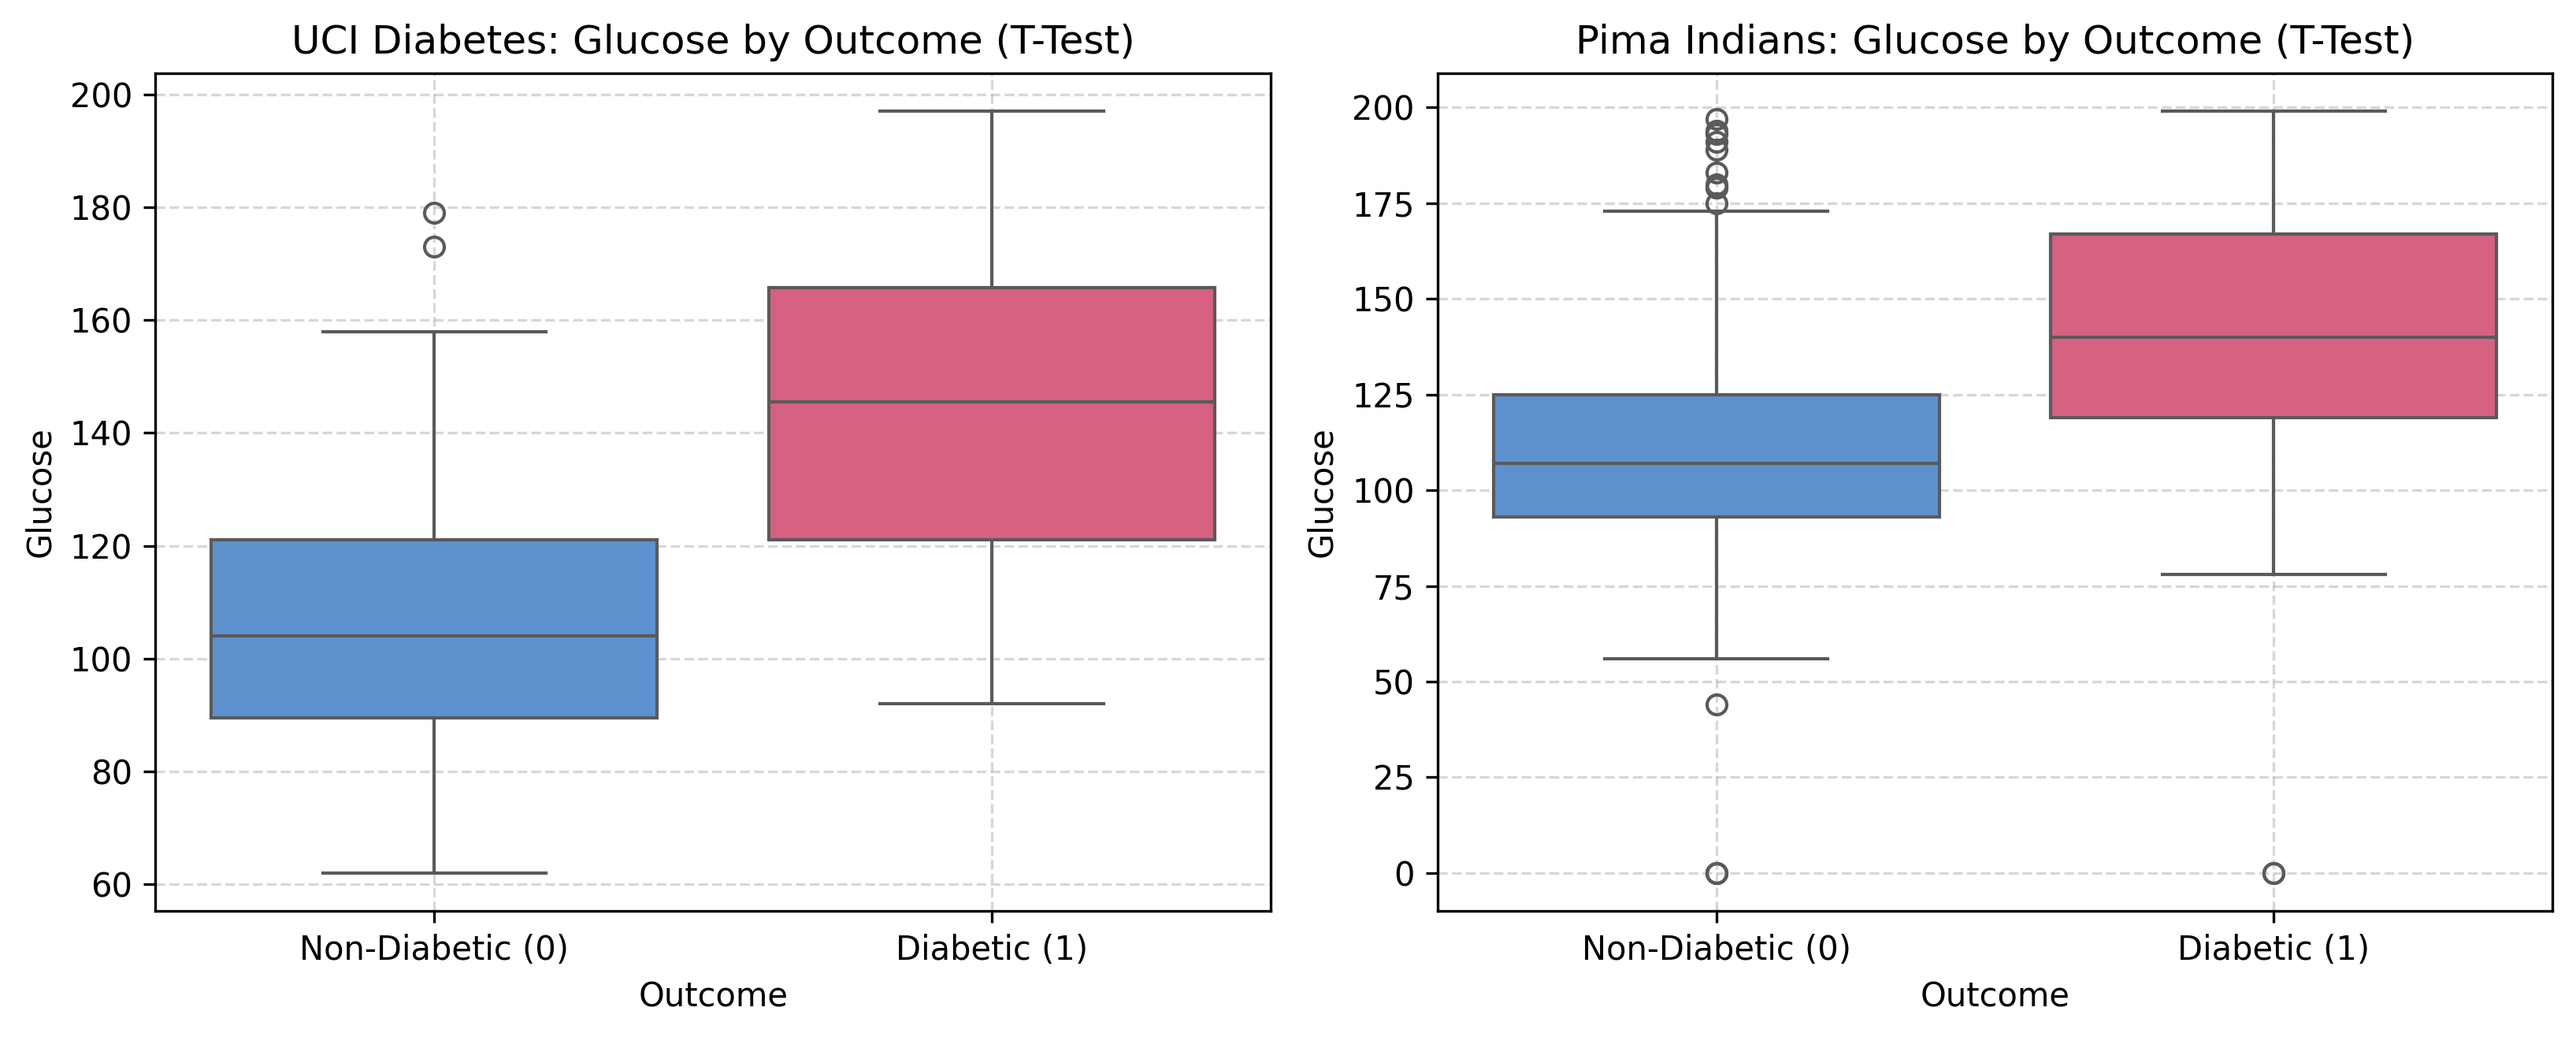

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=uci_diabetes, x='Outcome', y='Glucose', ax=axes[0], palette=['#4a90e2', '#e94e77'])
axes[0].set_title('UCI Diabetes: Glucose by Outcome (T-Test)')
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.boxplot(data=pima_diabetes, x='Outcome', y='Glucose', ax=axes[1], palette=['#4a90e2', '#e94e77'])
axes[1].set_title('Pima Indians: Glucose by Outcome (T-Test)')
axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()